In [159]:
########## Varying Parameters ##########
n_sim = 1000
n = int(2001/0.7)
B_RF = int(n*0.7 /2)


data_generation_parameter  =  { 'shape_weibull': 1,  'p_1': -0.4, 'p_2': -0.2, 'p_3': -0.1, 'n': n,
                                    'scale_weibull_base':   5_329_174_608_059        , 
                                    'rate_censoring':       0.04477    , 
                                    'tau': 20, }  

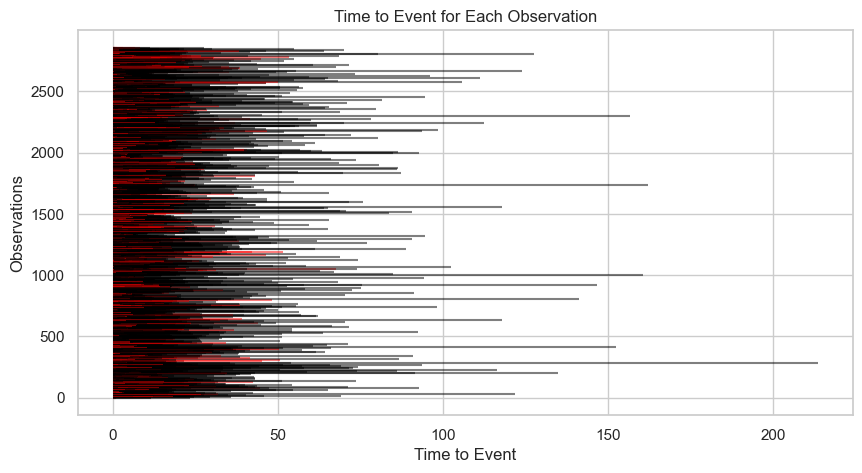

survived
999    0.5
1      0.3
0      0.2
Name: proportion, dtype: float64

In [160]:
from utils import create_weibull_data, create_data_with_ipc_weights
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd

train_models= False
ijk_wager_calc= False
ijk_butt_calc= False
ijk2_butt_calc= False
boot_calc= False
if boot_calc:
    B_first_level  = 3
else: 
    B_first_level  = 0
seed = 42
X_pred_point = pd.DataFrame({'X_1': [40], 'X_2': [1], 'X_3': [80]})



aa = create_weibull_data(data_generation_parameter, 42)
plt.figure(figsize=(10, 5))
sns.set(style="whitegrid")
for i in range(len(aa)):
    if aa['event'].iloc[i]:
        plt.hlines(y=i, xmin=0, xmax=aa['time'].iloc[i], color='red', alpha=0.5)
    else:
        plt.hlines(y=i, xmin=0, xmax=aa['time'].iloc[i], color='black', alpha=0.5)
plt.xlabel('Time to Event')
plt.ylabel('Observations')
plt.title('Time to Event for Each Observation')
plt.show()

bb = create_data_with_ipc_weights(data_generation_parameter, aa)
bb['survived'].value_counts(normalize=True).round(2)

In [57]:
from utils import simulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

### Simulations Parameter ##############
train_models= False
ijk_wager_calc= False
ijk_butt_calc= False
ijk2_butt_calc= False
boot_calc= False
if boot_calc: 
    B_first_level  = 3 
else: 
    B_first_level  = 0
seed = 42
X_pred_point = pd.DataFrame({'X_1': [40], 'X_2': [1], 'X_3': [80]})

########## Varying Parameters ##########
n_sim = 1000
n = int(2001/0.7)
B_RF = int(n*0.7 /2)


params_rf =         {   'n_estimators':B_RF,                        
                        'max_depth':4,
                        'min_samples_split':5,
                        'max_features': 'log2',
                        'random_state':  seed,
                        'weighted_bootstrapping': True, }



In [191]:
def find_parameters(target_event_portion, target_censored_portion, initial_scale, initial_rate):
    scale = initial_scale
    rate = initial_rate
    tolerance = 0.005  # Toleranzschwelle für die Anteile
    max_iterations = 500
    iteration = 0

    while iteration < max_iterations:
        # Aktualisieren der Parameter
        params_data_creation['scale_weibull_base'] = scale
        params_data_creation['rate_censoring'] = rate

        # Führen Sie eine einzelne Simulation durch
        result = simulation(
            seed=seed,
            B_first_level=B_first_level,
            train_models=train_models,
            ijk_wager_calc=ijk_wager_calc,
            ijk_butt_calc=ijk_butt_calc,
            ijk2_butt_calc=ijk2_butt_calc,
            boot_calc=boot_calc,
            data_generation_parameter=params_data_creation,
            params_rf=params_rf,
            X_pred_point = X_pred_point,
        )

        # Extrahieren der Anteile
        event_portion = result[8][0]  # Portion of events after cut (Annahme)
        censored_portion = result[8][999]  # Portion of censored after cut (Annahme)

        # Überprüfung der Anteile
        if abs(event_portion - target_event_portion) < tolerance and abs(censored_portion - target_censored_portion) < tolerance:
            print(f"Gewünschte Anteile erreicht bei  \nscale_weibull_base=  {scale} \nund rate_censoring=  {rate}")
            break
        
        ss = 0.01
        
        # Anpassen der Parameter basierend auf der Differenz
        if event_portion < target_event_portion:
            scale -= scale * ss  # Verringern Sie scale_weibull_base um 5%
        else:
            scale += scale * ss  # Erhöhen Sie scale_weibull_base um 5%

        if censored_portion < target_censored_portion:
            rate += rate * ss  # Erhöhen Sie rate_censoring um 5%
        else:
            rate -= rate * ss  # Verringern Sie rate_censoring um 5%

        iteration += 1

    if iteration == max_iterations:
        print("Maximale Anzahl von Iterationen erreicht. Gewünschte Anteile nicht gefunden.")
        
    return scale, rate
        
########################################################################

n = int(1000.5/0.7)
params_data_creation  =  { 'shape_weibull': 1,  'p_1': -0.4, 'p_2': -0.2, 'p_3': -0.1, 'n': n,
                                    'scale_weibull_base':   0       , 
                                    'rate_censoring':       0.09 * 10_00000000    , 
                                    'tau': 20, }  

s,r = find_parameters(0.205, 0.5, 1000000000000 , 0.04)


Gewünschte Anteile erreicht bei  
scale_weibull_base=  4865174608059.983 
und rate_censoring=  0.04610558336547693


In [7]:
import pandas as pd
X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})
params_data_creation =   { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': 100,
                                'scale_weibull_base':   22_080       , 
                                'rate_censoring':       0.00321    , 
                                'tau': 37, 
                                'data_type':           'weibull'               ,
                                'X_pred_point': X_pred_point}  
params_data_creation['X_pred_point'].shape[1]

4

In [14]:
from utils import simulation
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

########## Varying Parameters ##########
n_sim = 1000
n = int(1000.5/0.7)
B_RF = int(n*0.7 /2)
seed = 42


params_rf =         {   'n_estimators':B_RF,                        
                        'max_depth':4,
                        'min_samples_split':5,
                        'max_features': 'log2',
                        'random_state':  seed,
                        'weighted_bootstrapping': True, }


X_pred_point = pd.DataFrame({'X_1': [0], 'X_2': [1], 'X_3': [80], 'X_4': [40]})

pdd =  { 'shape_weibull': 1,  'p_1': -0.405, 'p_2': -0.4, 'p_3': -0.05, 'p_4': -0.01, 'n': n,
                                    'scale_weibull_base':  15120        , 
                                    'rate_censoring':       0.023293   , 
                                    'tau': 37, 
                                    'X_pred_point': X_pred_point }

with ProcessPoolExecutor() as executor:
    ### Array to store the results
    wb_test_mse = np.zeros(n_sim)
    rf_test_mse = np.zeros(n_sim)
    rf_pred = np.zeros(n_sim)
    wb_pred = np.zeros(n_sim)
    ijk_butt_var = np.zeros(n_sim)
    ijk_u_butt_var = np.zeros(n_sim)
    ijk_u2_butt_var = np.zeros(n_sim)
    ijk_jahn_var = np.zeros(n_sim)
    ijk_u_jahn_var = np.zeros(n_sim)
    ijk_u2_jahn_var = np.zeros(n_sim)
    ijk_wager_var = np.zeros(n_sim)
    ijk_u_wager_var = np.zeros(n_sim)
    jk_wager_var = np.zeros(n_sim)
    jk_u_wager_var = np.zeros(n_sim)
    boot_var = np.zeros(n_sim)

    portion_zero_weights_train = np.zeros(n_sim)
    portion_seen_events_train = np.zeros(n_sim)
    portion_zero_weights_test = np.zeros(n_sim)
    portion_seen_events_test = np.zeros(n_sim)

    futures = [ executor.submit(  
                                  simulation,
                                  seed=seed+i,
                                  data_generation_parameter=pdd,
                                  params_rf=params_rf,
                                  train_models=False,
                                  ijk_wager_calc=False,
                                  ijk_butt_calc=False,
                                  ijk_jahn_calc=False,
                                  jk_wager_calc=False,
                                  boot_calc=[False, 0 ],)
                for i in range(n_sim) ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _wb_test_mse, _rf_test_mse, _wb_pred, _rf_pred, _ijk_butt_var, _ijk_jahn_var, _ijk_wager_var, _jk_wager_var, _boot_var, _survived_stats_train,_survived_stats_test   = future.result()

        #Event-Stats Results
        portion_zero_weights_train[i] = _survived_stats_train[999]
        portion_seen_events_train[i] = _survived_stats_train[0]
        portion_zero_weights_test[i] = _survived_stats_test[999]
        portion_seen_events_test[i] = _survived_stats_test[0]

def print_stats_data():

    print('Event-Stats Results:')
    print('Train:')
    print(f'Portion of events after cut:     {round(np.mean(portion_seen_events_train)*100,2)}%,   n={round(n*0.7*np.mean(portion_seen_events_train),0)}')
    print(f'Portion of censored after cut:   {round(np.mean(portion_zero_weights_train)*100,2)}%,   n={round(n*0.7*np.mean(portion_zero_weights_train),0)}\n')
    print('Test:')
    print(f'Portion of events after cut:     {round(np.mean(portion_seen_events_test)*100,2)}%,   n={round(n*0.3*np.mean(portion_seen_events_test),0)}')
    print(f'Portion of censored after cut:   {round(np.mean(portion_zero_weights_test)*100,2)}%,   n={round(n*0.3*np.mean(portion_zero_weights_test),0)}')
    print('\n')
print('\n')
print_stats_data()

Simulations: 100%|██████████| 1000/1000 [00:05<00:00, 179.24simulation/s]




Event-Stats Results:
Train:
Portion of events after cut:     19.98%,   n=200.0
Portion of censored after cut:   50.04%,   n=501.0

Test:
Portion of events after cut:     20.0%,   n=86.0
Portion of censored after cut:   49.99%,   n=214.0


